# German Credit: Distributional Constraint Audit of GLOBE-CE

Without modifying the GLOBE-CE algorithm, this notebook reuses the German Credit data split, MLP model, and 100 explained samples from the paper. GLOBE-CE first generates a global counterfactual transformation for samples assigned an unfavorable outcome; the generated samples are then recombined into an empirical distribution and audited against the four institutional constraints studied in the CDCE paper.

The main outputs include coverage, input-space SWD, output-space WD, and metrics for the Mean, Standard deviation, Linear structural, and FSD constraint families.

## 1. Experimental Setup

- Data split: 80% training and 20% test data with random seed 42.
- Prediction model: an MLP with two hidden layers of width 10, trained for 300 epochs.
- Explained samples: a fixed sample of 100 observations from the test set.
- Target output: consistent with the paper, target scores are sampled from $\mathrm{Beta}(0.1, 0.9)$.
- GLOBE-CE: recourse is sought only for samples currently predicted as bad; samples without successful recourse retain their factual values.

This experiment uses the repository's existing port of the official algorithm in `explainers/globe_ce.py`. To remain consistent with CDCE's nine-dimensional input and the same MLP, all nine preprocessed input columns are supplied to GLOBE-CE as numerical coordinates. This is a data-interface adaptation and does not alter its search or scaling algorithm.

In [1]:
import os
import sys
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "explainers").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")

REPO_ROOT = find_repo_root()
BASELINE_DIR = REPO_ROOT / "baselines" / "globe-ce"
sys.path.insert(0, str(REPO_ROOT))

from explainers.constraints.FSDConstraint import FSDConstraintTorch
from explainers.distances import SlicedWassersteinDivergence, WassersteinDivergence
from explainers.globe_ce import GLOBE_CE
from models.mlp import BlackBoxModel

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
SAMPLE_SIZE = 100
TRIM_DELTA = 0.1
N_PROJECTIONS = 10
GLOBE_DIRECTION_SAMPLES = 5000
DATA_DIR = REPO_ROOT / "germancredit"
OUTPUT_DIR = BASELINE_DIR / "results" / "german-credit"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch: 2.6.0+cpu
CUDA available: False


## 2. Data Preprocessing and Prediction Model

This section exactly reuses the feature encoding, missing-value handling, standardization, and model-training procedure from the original German Credit notebook. The labels are `good = 0` and `bad = 1`, so a lower model output score represents a more favorable credit outcome.

In [2]:
raw_df = pd.read_csv(REPO_ROOT / "data/german_credit/german_credit_data.csv")
df = raw_df.copy()
target_name = "Risk"
target = df[target_name].replace({"good": 0, "bad": 1})
df[target_name] = target

saving_map = {"little": 1, "moderate": 2, "quite rich": 3, "rich": 4}
checking_map = {"little": 1, "moderate": 2, "rich": 3}
housing_map = {"free": 0, "rent": 1, "own": 2}
label_encoder = LabelEncoder()

for column in df.columns:
    if column != target_name and df[column].dtype == "object":
        if column == "Saving accounts":
            df[column] = df[column].map(saving_map)
        elif column == "Checking account":
            df[column] = df[column].map(checking_map)
        elif column == "Housing":
            df[column] = df[column].map(housing_map)
        else:
            df[column] = label_encoder.fit_transform(df[column].astype(str))

for column in df.columns:
    if df[column].isna().any():
        df[column] = df[column].fillna(df[column].median()).astype(int)

features = [
    "Age", "Sex", "Job", "Housing", "Saving accounts",
    "Checking account", "Credit amount", "Duration", "Purpose"
]
X_all = df[features].copy()
y_all = target.copy()

set_seed()
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED
)
train_mean = X_train_raw.mean()
train_std = X_train_raw.std()
X_train = (X_train_raw - train_mean) / train_std
X_test = (X_test_raw - train_mean) / train_std

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

set_seed()
model = BlackBoxModel(input_dim=X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for _ in range(300):
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

model.eval()
with torch.no_grad():
    test_scores = model(X_test_tensor).reshape(-1)
    test_predictions = (test_scores >= 0.5).float()
    test_accuracy = (test_predictions == y_test_tensor.reshape(-1)).float().mean().item()

sample_indices = X_test.sample(SAMPLE_SIZE, random_state=SEED).index
factual_norm = X_test.loc[sample_indices].copy()
factual_raw = X_test_raw.loc[sample_indices].copy()
y_true = y_test.loc[sample_indices].copy()

set_seed()
y_target = torch.distributions.beta.Beta(0.1, 0.9).sample((SAMPLE_SIZE,))
with torch.no_grad():
    factual_scores = model(torch.tensor(factual_norm.values, dtype=torch.float32)).reshape(-1)

print(f"Test accuracy: {test_accuracy:.3f}")
print(f"Explained population: {len(factual_norm)} samples")
print(f"Bad predictions in explained population: {int((factual_scores >= 0.5).sum())}")

C:\Users\mingx\AppData\Local\Temp\ipykernel_1972\3753502695.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target = df[target_name].replace({"good": 0, "bad": 1})


Test accuracy: 0.755
Explained population: 100 samples
Bad predictions in explained population: 20


## 3. Run GLOBE-CE Without Algorithmic Modification

The original GLOBE-CE implementation treats class 1 as the desired outcome, whereas class 0 is good in the current model. The wrapper below only reverses the class semantics: it returns 1 to GLOBE-CE when the original model predicts good and 0 when it predicts bad. The decision boundary and model parameters remain unchanged.

GLOBE-CE first performs a random search for a shared transformation direction and then selects, for each affected sample, the smallest scaling coefficient along that direction that flips the prediction.

In [3]:
class FavorableOutcomeModel:
    def __init__(self, base_model):
        self.base_model = base_model

    def predict(self, X):
        tensor = torch.as_tensor(X, dtype=torch.float32)
        with torch.no_grad():
            bad_scores = self.base_model(tensor).reshape(-1)
        return (bad_scores < 0.5).to(torch.int64).cpu().numpy()


class GlobeDatasetMetadata:
    def __init__(self, feature_names):
        self.name = "german_credit_cdce"
        self.features_tree = {name: [] for name in feature_names}
        self.features = list(feature_names) + ["Outcome"]
        self.categorical_features = {self.name: []}
        self.continuous_features = {self.name: list(feature_names)}


globe_model = FavorableOutcomeModel(model)
globe_dataset = GlobeDatasetMetadata(features)

set_seed()
globe = GLOBE_CE(
    model=globe_model,
    dataset=globe_dataset,
    X=factual_norm,
    normalise=None,
    p=1,
)

start_time = time.perf_counter()
globe.sample(
    n_sample=GLOBE_DIRECTION_SAMPLES,
    magnitude=1.0,
    sparsity_power=1.0,
    disable_tqdm=False,
    seed=SEED,
    scheme="random",
)

scaled_correctness, scaled_costs, scalars = globe.scale(
    globe.best_delta,
    scalars="auto",
    n_scalars=1000,
    vector=True,
    disable_tqdm=False,
)
_, first_success_indices = globe.min_scalar_costs(
    scaled_costs, return_idxs=True, remove_nan=False
)
runtime_seconds = time.perf_counter() - start_time

affected_counterfactuals = globe.x_aff.copy()
successful_recourse = ~np.isnan(first_success_indices)
for row_idx in np.where(successful_recourse)[0]:
    scalar_idx = int(first_success_indices[row_idx])
    affected_counterfactuals[row_idx] = (
        globe.x_aff[row_idx] + scalars[scalar_idx] * globe.best_delta
    )

affected_mask = globe_model.predict(factual_norm.values) == 0
globe_cf_norm = factual_norm.copy()
globe_cf_norm.loc[affected_mask, features] = affected_counterfactuals
globe_cf_raw = globe_cf_norm * train_std[features] + train_mean[features]

with torch.no_grad():
    globe_scores = model(torch.tensor(globe_cf_norm.values, dtype=torch.float32)).reshape(-1)

affected_coverage = successful_recourse.mean() if len(successful_recourse) else 1.0
population_favorable_rate = (globe_scores < 0.5).float().mean().item()

print(f"Affected samples: {len(globe.x_aff)}")
print(f"Successful recourse: {int(successful_recourse.sum())}/{len(successful_recourse)}")
print(f"Coverage among affected samples: {affected_coverage:.3f}")
print(f"Favorable rate in final population: {population_favorable_rate:.3f}")
print(f"Runtime: {runtime_seconds:.2f} seconds")

  0%|          | 0/5000 [00:00<?, ?it/s]

 12%|█▏        | 609/5000 [00:00<00:00, 6036.87it/s]

 29%|██▊       | 1432/5000 [00:00<00:00, 6766.34it/s]

 44%|████▍     | 2205/5000 [00:00<00:00, 7165.68it/s]

 59%|█████▉    | 2943/5000 [00:00<00:00, 7233.94it/s]

...

 88%|████████▊ | 4376/5000 [00:00<00:00, 7008.06it/s]

100%|██████████| 5000/5000 [00:00<00:00, 7140.24it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:00<00:00, 14312.49it/s]

Unable to find recourse for 0/20 inputs
Affected samples: 20
Successful recourse: 20/20
Coverage among affected samples: 1.000
Favorable rate in final population: 1.000
Runtime: 0.79 seconds


## 4. Unified Evaluation Functions

The four constraints follow the definitions used in the paper's German Credit case study:

1. **Mean**: the mean of `Duration` should be at least 21.
2. **Standard deviation**: the standard deviation of `Credit amount` should be at most 2000.
3. **Linear structural constraint**: evaluate `Duration = 0.6264 × Credit amount` in standardized space, report the residual MSE, and use 0.6069 as the tolerance threshold.
4. **FSD**: shorter `Duration` is preferred; report the violation points of the empirical CDF.

Mean and standard-deviation violations use the original-scale distance beyond the feasible interval. LSC reports both MSE and the average hinge violation beyond the tolerance.

In [4]:
def evaluate_constraints(factual_raw_df, counterfactual_raw_df, counterfactual_norm_df):
    duration_mean = float(counterfactual_raw_df["Duration"].mean())
    credit_std = float(counterfactual_raw_df["Credit amount"].std(ddof=0))

    duration_norm = counterfactual_norm_df["Duration"].to_numpy(dtype=float)
    credit_norm = counterfactual_norm_df["Credit amount"].to_numpy(dtype=float)
    residual_sq = (duration_norm - 0.6264 * credit_norm) ** 2
    structural_mse = float(residual_sq.mean())
    structural_hinge = float(np.maximum(residual_sq - 0.6069, 0.0).mean())

    fsd_result = FSDConstraintTorch.check_FSD(
        factual_raw_df["Duration"].to_numpy(dtype=float),
        counterfactual_raw_df["Duration"].to_numpy(dtype=float),
        direction=-1,
    )

    return {
        "Duration mean": duration_mean,
        "Mean violation": max(21.0 - duration_mean, 0.0),
        "Credit amount std": credit_std,
        "Std violation": max(credit_std - 2000.0, 0.0),
        "Structural MSE": structural_mse,
        "Structural hinge violation": structural_hinge,
        "FSD violations": len(fsd_result["violations"]),
        "FSD holds": bool(fsd_result["holds"]),
        "FSD interval ratio": float(fsd_result["interval_ratio"]),
    }


def compute_distribution_metrics(factual_norm_df, counterfactual_norm_df, cf_scores, target_scores):
    set_seed()
    swd = SlicedWassersteinDivergence(
        dim=factual_norm_df.shape[1], n_proj=N_PROJECTIONS
    )
    wd = WassersteinDivergence()
    factual_tensor = torch.tensor(factual_norm_df.values, dtype=torch.float32)
    counterfactual_tensor = torch.tensor(counterfactual_norm_df.values, dtype=torch.float32)
    score_tensor = torch.as_tensor(cf_scores, dtype=torch.float32).reshape(-1)
    target_tensor = torch.as_tensor(target_scores, dtype=torch.float32).reshape(-1)

    x_swd = np.sqrt(swd.distance(counterfactual_tensor, factual_tensor, TRIM_DELTA)[0].item())
    y_wd = np.sqrt(wd.distance(score_tensor, target_tensor, TRIM_DELTA)[0].item())
    return float(x_swd), float(y_wd)

globe_constraint_metrics = evaluate_constraints(factual_raw, globe_cf_raw, globe_cf_norm)
globe_swd, globe_wd = compute_distribution_metrics(
    factual_norm, globe_cf_norm, globe_scores, y_target
)

globe_summary = {
    "Method": "GLOBE-CE",
    "Coverage": affected_coverage,
    "Favorable rate": population_favorable_rate,
    "SWD": globe_swd,
    "WD": globe_wd,
    "Runtime (s)": runtime_seconds,
    **globe_constraint_metrics,
}
display(pd.DataFrame([globe_summary]).round(4))

,Method,Coverage,Favorable rate,SWD,WD,Runtime (s),Duration mean,Mean violation,Credit amount std,Std violation,Structural MSE,Structural hinge violation,FSD violations,FSD holds,FSD interval ratio
0,GLOBE-CE,1.0,1.0,0.0743,0.1915,0.7928,18.542,2.458,2113.0421,113.0421,0.6367,0.3226,0,True,1.0


## 5. Paper-Style Tables with Existing DCE/CDCE Results

The repository already contains the factual, DCE, and four CDCE outputs for the paper's German Credit case study. The cells below read these files directly and recompute the metrics with the same evaluation functions. Because the four CDCE constraints are activated in separate experiments, the constraint table reports one row per constraint family rather than treating the four CDCE outputs as a single joint solution.

In [5]:
def load_counterfactual_excel(filename):
    frame = pd.read_excel(DATA_DIR / filename, sheet_name="counterfactual", index_col=0)
    raw_features = frame[features].copy()
    normalized_features = (raw_features - train_mean[features]) / train_std[features]
    scores = frame["y_cf_pred"].to_numpy(dtype=float) if "y_cf_pred" in frame else None
    return raw_features, normalized_features, scores

existing_files = {
    "DCE": "counterfactual.xlsx",
    "CDCE (Mean)": "mean_constraint_21_100.xlsx",
    "CDCE (Std)": "std_constraint_2000_100.xlsx",
    "CDCE (LSC)": "lsc_hinge_constraint.xlsx",
    "CDCE (FSD)": "fsd_constraint.xlsx",
}

loaded_results = {}
for method_name, filename in existing_files.items():
    file_path = DATA_DIR / filename
    if file_path.exists():
        raw_features, normalized_features, scores = load_counterfactual_excel(filename)
        loaded_results[method_name] = {
            "raw": raw_features,
            "norm": normalized_features,
            "scores": scores,
            "constraints": evaluate_constraints(
                factual_raw.reset_index(drop=True),
                raw_features.reset_index(drop=True),
                normalized_features.reset_index(drop=True),
            ),
        }

alignment_rows = [globe_summary]
if "DCE" in loaded_results:
    dce = loaded_results["DCE"]
    dce_saved_metrics = pd.read_excel(
        DATA_DIR / "counterfactual.xlsx", sheet_name="metrics"
    ).iloc[0]
    dce_swd = float(dce_saved_metrics["X_SWD_no_constraint"])
    dce_wd = float(dce_saved_metrics["Y_WD_no_constraint"])
    alignment_rows.insert(0, {
        "Method": "DCE",
        "Coverage": float(np.mean(dce["scores"] < 0.5)),
        "Favorable rate": float(np.mean(dce["scores"] < 0.5)),
        "SWD": dce_swd,
        "WD": dce_wd,
        "Runtime (s)": np.nan,
        **dce["constraints"],
    })

alignment_table = pd.DataFrame(alignment_rows)[
    ["Method", "Coverage", "Favorable rate", "SWD", "WD", "Runtime (s)"]
]
display(alignment_table.round(4).style.set_caption("Table 1. German Credit distributional alignment"))

paper_reference = {
    "Mean": {"DCE": 18.95, "CDCE": 20.97},
    "Standard deviation": {"DCE": 2155.30, "CDCE": 2000.60},
    "Linear structure": {"DCE": 0.6555, "CDCE": 0.3030},
    "FSD": {"DCE": 54, "CDCE": 17},
}

constraint_specs = [
    ("Mean", "Duration ≥ 21", "Duration mean"),
    ("Standard deviation", "Credit amount ≤ 2000", "Credit amount std"),
    ("Linear structure", "Duration = 0.6264 × Credit amount", "Structural MSE"),
    ("FSD", "Duration shifts shorter", "FSD violations"),
]

constraint_rows = []
for family, target_text, metric_name in constraint_specs:
    constraint_rows.append({
        "Constraint family": family,
        "Feasibility target": target_text,
        "Metric": metric_name,
        "DCE (paper)": paper_reference[family]["DCE"],
        "GLOBE-CE": globe_constraint_metrics[metric_name],
        "CDCE (paper)": paper_reference[family]["CDCE"],
    })

constraint_table = pd.DataFrame(constraint_rows)
display(constraint_table.round(4).style.set_caption("Table 2. German Credit constraint-specific results"))

,Method,Coverage,Favorable rate,SWD,WD,Runtime (s)
0,DCE,0.890000,0.890000,0.044200,0.068200,nan
1,GLOBE-CE,1.000000,1.000000,0.074300,0.191500,0.792800


,Constraint family,Feasibility target,Metric,DCE (paper),GLOBE-CE,CDCE (paper)
0,Mean,Duration ≥ 21,Duration mean,18.950000,18.542000,20.970000
1,Standard deviation,Credit amount ≤ 2000,Credit amount std,2155.300000,2113.042100,2000.600000
2,Linear structure,Duration = 0.6264 × Credit amount,Structural MSE,0.655500,0.636700,0.303000
3,FSD,Duration shifts shorter,FSD violations,54.000000,0.000000,17.000000


## 6. Visual Diagnostics

The left panel checks whether the generated model scores move toward the target output; the right panel examines the empirical CDF of Duration. When shorter Duration is preferred, the counterfactual CDF should shift left relative to the factual CDF while minimizing local crossings.

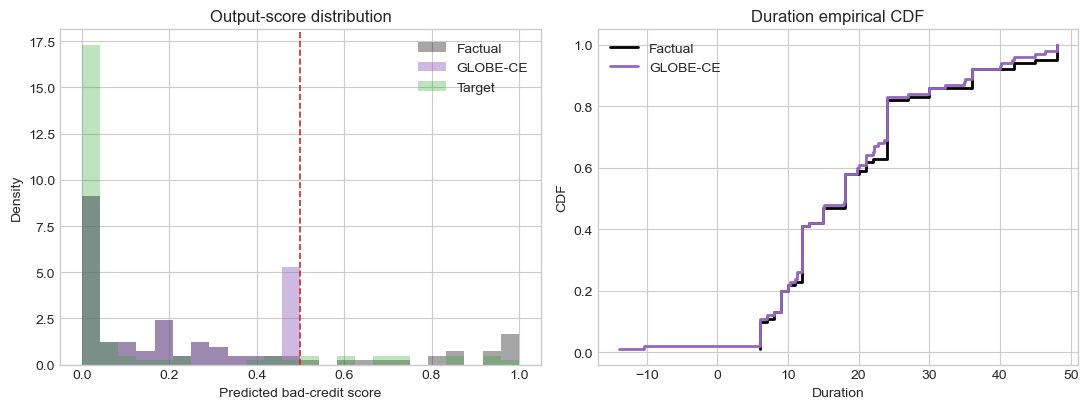

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

bins = np.linspace(0, 1, 25)
axes[0].hist(factual_scores.detach().numpy(), bins=bins, density=True, alpha=0.35, label="Factual", color="black")
axes[0].hist(globe_scores.detach().numpy(), bins=bins, density=True, alpha=0.45, label="GLOBE-CE", color="tab:purple")
axes[0].hist(y_target.detach().numpy(), bins=bins, density=True, alpha=0.30, label="Target", color="tab:green")
axes[0].axvline(0.5, color="tab:red", linestyle="--", linewidth=1.2)
axes[0].set_title("Output-score distribution")
axes[0].set_xlabel("Predicted bad-credit score")
axes[0].set_ylabel("Density")
axes[0].legend()

for values, label, color in [
    (factual_raw["Duration"].to_numpy(), "Factual", "black"),
    (globe_cf_raw["Duration"].to_numpy(), "GLOBE-CE", "tab:purple"),
]:
    sorted_values = np.sort(values)
    empirical_cdf = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
    axes[1].step(sorted_values, empirical_cdf, where="post", linewidth=2, label=label, color=color)

axes[1].set_title("Duration empirical CDF")
axes[1].set_xlabel("Duration")
axes[1].set_ylabel("CDF")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Save Results

Save the complete 100-person counterfactual distribution generated by GLOBE-CE together with two summary tables. The output files do not overwrite the paper's existing DCE/CDCE results.

In [7]:
globe_export = globe_cf_raw.copy()
globe_export["y_true"] = y_true.to_numpy()
globe_export["y_cf_pred"] = globe_scores.detach().numpy()
globe_export["y_target"] = y_target.detach().numpy()
globe_export["was_affected"] = affected_mask
globe_export["recourse_success"] = False
globe_export.loc[affected_mask, "recourse_success"] = successful_recourse

excel_path = OUTPUT_DIR / "globe_ce_constraint_audit.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    globe_export.to_excel(writer, sheet_name="counterfactual", index=True)
    alignment_table.to_excel(writer, sheet_name="alignment", index=False)
    constraint_table.to_excel(writer, sheet_name="constraints", index=False)

alignment_table.to_csv(OUTPUT_DIR / "globe_ce_alignment.csv", index=False)
constraint_table.to_csv(OUTPUT_DIR / "globe_ce_constraint_results.csv", index=False)

print(f"Saved counterfactuals and tables to: {excel_path}")

Saved counterfactuals and tables to: germancredit\globe_ce_constraint_audit.xlsx


## 8. Interpretation Template

The results should not describe GLOBE-CE as a failed method. A more accurate interpretation is that GLOBE-CE is designed to provide high-coverage global recourse through a shared translation, rather than explicitly controlling the generated population's moments, structural relations, or stochastic order.

If the experiment shows that GLOBE-CE improves the favorable rate while substantial violations remain for the four constraints, the following wording can be used:

> GLOBE-CE successfully provides global recourse for a substantial fraction of affected instances. However, aggregating these recourses does not automatically satisfy the institutional constraints imposed on the resulting empirical distribution. CDCE directly addresses this gap by incorporating distribution-level feasibility requirements into the counterfactual optimization objective.